In [1]:
import sys
import os
import numpy as np

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_initial_circuit2, concatenate_circuits_with_separate_measurements, add_cnots_and_measurements_to_circuit
from quantum_functions import add_crx_gates_and_measurements_to_circuit, get_probability_distribution, calculate_kl_divergence
from quantum_functions import score_circuit_kl_divergences, plot_measurement_histograms, create_cnot_pairs_from_locations, optimize_crx_angles
from quantum_functions import _process_target_state_input
from quantum_functions import find_best_cnot_sequence_brute_force, find_best_cnot_sequence_multi_epoch
from quantum_functions import vector_normalize_dictionary_values, find_best_cnot_sequence_iterative_n_wise

In [2]:
from qiskit import QuantumCircuit, QuantumRegister

def create_hadamard_circuit(num_qubits: int) -> QuantumCircuit:
    """
    Initializes a quantum circuit with all qubits in the |+> state by
    applying a Hadamard gate to each one.

    Args:
        num_qubits (int): The number of qubits to include in the circuit.

    Returns:
        QuantumCircuit: The initialized quantum circuit.
    """
    # Create a quantum register with the specified number of qubits.
    qr = QuantumRegister(num_qubits, name='q')
    
    # Create a quantum circuit with the quantum register.
    circuit = QuantumCircuit(qr)
    
    # Loop through each qubit and apply the Hadamard (H) gate.
    # The H gate puts the qubit into a superposition of |0> and |1>.
    for i in range(num_qubits):
        circuit.h(qr[i])
        
    return circuit

from qiskit import QuantumCircuit, QuantumRegister
import math

def create_rotation_circuit(angles_list: list[float]) -> QuantumCircuit:
    """
    Initializes a quantum circuit by applying a rotation gate with a
    specified angle to each qubit. The number of qubits is determined
    by the length of the angles_list.

    Args:
        angles_list (list[float]): A list of rotation angles in radians,
                                   one for each qubit.

    Returns:
        QuantumCircuit: The initialized quantum circuit.
    """
    # The number of qubits is determined by the length of the angles list.
    num_qubits = len(angles_list)
    
    # Create a quantum register with the specified number of qubits.
    qr = QuantumRegister(num_qubits, name='q')
    
    # Create a quantum circuit with the quantum register.
    circuit = QuantumCircuit(qr)

    for i in range(num_qubits):
        circuit.ry(angles_list[i], qr[i])
        
    return circuit

import numpy as np
import pandas as pd
import anndata as ad
from scipy.stats import nbinom
import scanpy as sc

# --- Re-using the gene count matrix function for demonstration ---
def create_count_matrix_nbinom(binary_matrix: np.ndarray, mu_vector: np.ndarray, r_vector: np.ndarray):
    """
    Creates a count matrix from a binary matrix using a Negative Binomial distribution
    with gene-specific mean and dispersion parameters.
    """
    num_cells, num_genes = binary_matrix.shape
    
    if len(mu_vector) != num_genes or len(r_vector) != num_genes:
        raise ValueError("The length of mu_vector and r_vector must match the number of genes.")
        
    count_matrix = np.zeros_like(binary_matrix, dtype=np.int32)
    
    for j in range(num_genes):
        on_indices = np.where(binary_matrix[:, j] == 1)[0]
        mu_j = mu_vector[j]
        r_j = r_vector[j]
        p_j = r_j / (mu_j + r_j)
        random_counts = nbinom.rvs(n=r_j, p=p_j, size=len(on_indices))
        count_matrix[on_indices, j] = random_counts
        
    return count_matrix

import numpy as np

def create_binary_matrix(joint_counts: dict):
    """
    Generates a binary matrix from a joint histogram dictionary with 0s and 1s.

    Args:
        joint_counts (dict): A dictionary where keys are bit strings
                             (representing rows) and values are their counts.

    Returns:
        np.ndarray: A reconstructed binary matrix with integer values.
    """
    if not joint_counts:
        return np.array([], dtype=int).reshape(0, 0)
    
    # Get the number of genes (columns) from the length of the first key
    first_key = next(iter(joint_counts.keys()))
    num_genes = len(first_key)
    
    reconstructed_rows = []

    # Iterate through the joint counts
    for bit_string, count in joint_counts.items():
        # Reverse the bit string to align with the original g0, g1, ... order
        reversed_bit_string = bit_string[::-1]
        
        # Convert the reversed bit string to a list of integer values (0 or 1)
        row_values = [int(char) for char in reversed_bit_string]
        
        # Repeat the row 'count' number of times
        for _ in range(count):
            reconstructed_rows.append(row_values)
            
    # Convert the list of lists into a NumPy array with integer dtype
    return np.array(reconstructed_rows, dtype=int)

In [ ]:
# Create the circuit using the function
ang_4g = [np.pi*0.2, np.pi*0.1, np.pi*0.4, np.pi*0.9, np.pi*0.8]
circuit_4g = create_rotation_circuit(ang_4g)
# Fn1 the last

# Create the circuit using the function
ang_3g = [np.pi*0.2, np.pi*0.3, np.pi*0.2, np.pi*0.7, np.pi*0.5]
circuit_3g = create_rotation_circuit(ang_3g)
# the last 2 are Cd44 and Sdc4

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


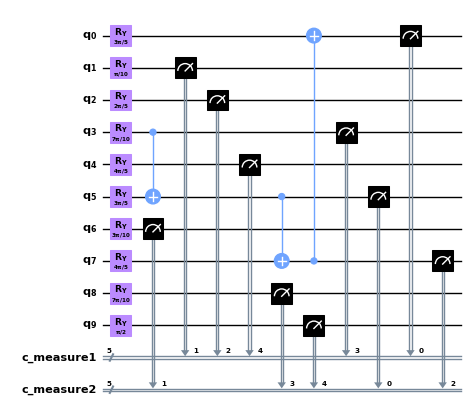

In [4]:
circuit_xct = concatenate_circuits_with_separate_measurements(circuit_4g, circuit_3g)
#interaction_map = list([(0,1), (2,1), (3,2), 
#                        (3,5), (5,7), (7,0)])
interaction_map = list([(3,5), (5,7), (7,0)])

circuit_xct_cnot = add_cnots_and_measurements_to_circuit(circuit_xct, circuit_4g.num_qubits, interaction_map )
circuit_xct_cnot.draw(output="mpl", style="clifford", fold=40,  scale = 0.5)


--- Simulating and Plotting Histograms for: Greedy Optimized Circuit ---
Counts for c_measure1: {'10101': 73, '01101': 31, '11101': 208, '11001': 423, '11000': 479, '10000': 108, '01100': 31, '01000': 57, '11100': 281, '10110': 2, '11111': 7, '00100': 4, '10001': 131, '00101': 5, '11110': 9, '01001': 34, '10100': 59, '00001': 12, '11011': 13, '00000': 17, '11010': 11, '10010': 2, '01111': 2, '10011': 1}
Counts for c_measure2: {'11001': 222, '01011': 44, '01100': 353, '11100': 354, '10100': 77, '11011': 65, '01010': 7, '01001': 232, '10001': 58, '01101': 24, '00001': 62, '11000': 29, '11110': 83, '01110': 86, '10011': 20, '00100': 95, '11101': 24, '01000': 44, '10010': 5, '10000': 5, '00000': 9, '00101': 9, '00011': 14, '11111': 7, '00110': 24, '10110': 20, '10101': 4, '11010': 10, '00010': 4, '01111': 7, '10111': 1, '00111': 2}


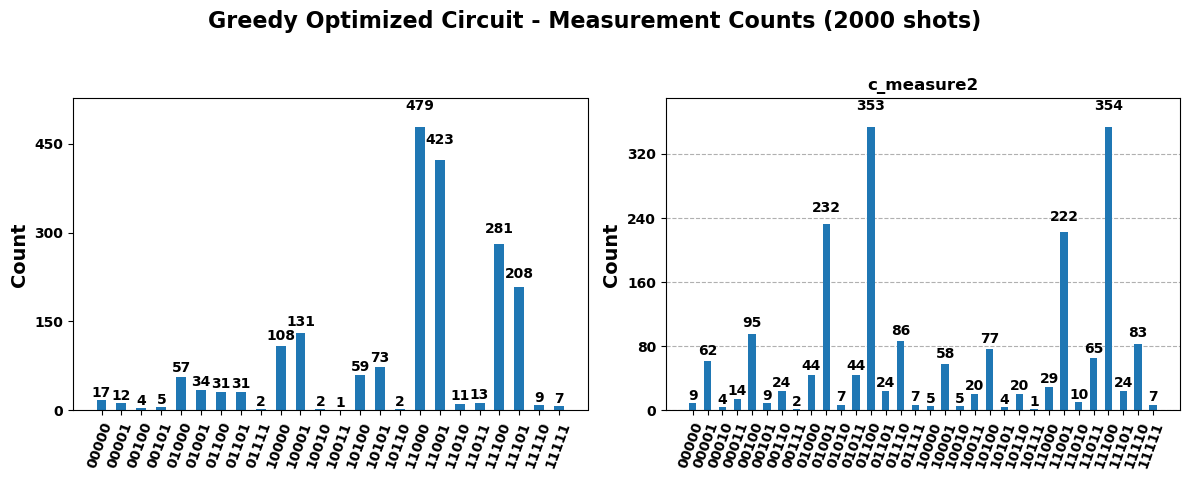

In [5]:
counts_measure1, counts_measure2 = plot_measurement_histograms(circuit_xct_cnot, nshots=2000, title_prefix="Greedy Optimized Circuit")

In [6]:
# Reconstruct the matrix
reconstructed_matrix = create_binary_matrix(counts_measure1)
print("Reconstructed Binary Matrix 1:")
print(reconstructed_matrix)
print("\nShape of the reconstructed matrix 1:", reconstructed_matrix.shape)

Reconstructed Binary Matrix 1:
[[1 0 1 0 1]
 [1 0 1 0 1]
 [1 0 1 0 1]
 ...
 [1 1 1 1 0]
 [1 1 1 1 0]
 [1 1 0 0 1]]

Shape of the reconstructed matrix 1: (2000, 5)


In [7]:
# Reconstruct the matrix
reconstructed_matrix2 = create_binary_matrix(counts_measure2)
print("Reconstructed Binary Matrix 1:")
print(reconstructed_matrix2)
print("\nShape of the reconstructed matrix 1:", reconstructed_matrix2.shape)

Reconstructed Binary Matrix 1:
[[1 0 0 1 1]
 [1 0 0 1 1]
 [1 0 0 1 1]
 ...
 [1 1 1 0 1]
 [1 1 1 0 0]
 [1 1 1 0 0]]

Shape of the reconstructed matrix 1: (2000, 5)


In [8]:
# Genes generated with stringdb:    https://string-db.org/cgi/network?taskId=bJEFw413SU2h&sessionId=bcTc0aENh3tL
# --- Step 1: Create the first AnnData object (representing one cell type) ---
print("Creating the first AnnData object (adata1)...")
 
# Simulating the first dataset's parameters
num_cells1 = 2000
gene_names1 = ['TGFBR2', 'FLT4', 'KDR', 'PDGFB', 'FN1']

# Set these genes to be highly expressed in this population
#mu_vector1 = np.array([4, 5, 2.5, 1, 3])
#r_vector1 = np.array([0.5, 0.4, 0.6, 0.7, 0.4])
mu_vector1 = np.array([5, 5, 5, 5, 5])
r_vector1 = np.array([1, 1, 1, 1, 1])

# Create dummy data for adata1
np.random.seed(100)
#binary_matrix1 = np.random.randint(0, 2, size=(num_cells1, len(gene_names1)))
count_matrix1 = create_count_matrix_nbinom(reconstructed_matrix, mu_vector1, r_vector1)

cell_ids1 = [f'cell_{i}_ds1_Co' for i in range(num_cells1)]
obs1 = pd.DataFrame(index=cell_ids1)
var1 = pd.DataFrame(index=gene_names1)

# Create the AnnData object for the first dataset
adata1 = ad.AnnData(X=count_matrix1, obs=obs1, var=var1)
print(f"adata1 shape: {adata1.shape}")
print(f"adata1 genes: {adata1.var_names.tolist()}")

Creating the first AnnData object (adata1)...
adata1 shape: (2000, 5)
adata1 genes: ['TGFBR2', 'FLT4', 'KDR', 'PDGFB', 'FN1']


In [9]:
# --- Step 2: Create the second AnnData object (representing another cell type) ---
print("\nCreating the second AnnData object (adata_mo_mo_mo_mo2)...")

num_cells2 = 2000
gene_names2 = ['PDGFRB', 'NRP1', 'TGFB1', 'CD44', 'SDC4']

# Set these genes to be highly expressed in this population
#mu_vector2 = np.array([2.5, 4.5, 3.5, 1, 2])
#r_vector2 = np.array([0.8, 0.6, 0.9, 0.7, 0.8])
mu_vector2 = np.array([5, 5, 5, 5, 5])
r_vector2 = np.array([1, 1, 1, 1, 1])

# Create dummy data for adata2
np.random.seed(200)
#binary_matrix2 = np.random.randint(0, 2, size=(num_cells2, len(gene_names2)))
count_matrix2 = create_count_matrix_nbinom(reconstructed_matrix2, mu_vector2, r_vector2)
cell_ids2 = [f'cell_{i}_ds2_Co' for i in range(num_cells2)]
obs2 = pd.DataFrame(index=cell_ids2)
var2 = pd.DataFrame(index=gene_names2)

# Create the AnnData object for the second dataset
adata2 = ad.AnnData(X=count_matrix2, obs=obs2, var=var2)
print(f"adata2 shape: {adata2.shape}")
print(f"adata2 genes: {adata2.var_names.tolist()}")


Creating the second AnnData object (adata_mo_mo_mo_mo2)...
adata2 shape: (2000, 5)
adata2 genes: ['PDGFRB', 'NRP1', 'TGFB1', 'CD44', 'SDC4']


In [10]:
# --- Step 3: Add housekeeping genes ---
print("\nAdding 10 random housekeeping genes to both datasets...")

num_housekeeping_genes = 50
housekeeping_gene_names = [f'HKG_{i}' for i in range(num_housekeeping_genes)]

# Housekeeping genes are highly and consistently expressed across all cells
mu_hkg = np.full(num_housekeeping_genes, 100.0)
r_hkg = np.full(num_housekeeping_genes, 5.0) # High r for low dispersion

# Create a binary matrix with 1s for all housekeeping genes across all cells
binary_matrix_hkg = np.ones((num_cells1 + num_cells2, num_housekeeping_genes), dtype=int)
count_matrix_hkg = create_count_matrix_nbinom(binary_matrix_hkg, mu_hkg, r_hkg)

# Create an AnnData object for the housekeeping genes
hkg_adata = ad.AnnData(
    X=count_matrix_hkg,
    obs=pd.DataFrame(index=list(adata1.obs_names) + list(adata2.obs_names)),
    var=pd.DataFrame(index=housekeeping_gene_names)
)

# --- Step 4: Merge the datasets ---
print("\nMerging all three AnnData objects...")

# First, merge adata1 and adata2 by cells
merged_cell_adata = ad.concat(
    [adata1, adata2],
    axis=0,
    join='outer',
    label='BatchID',
    keys=['ds1_Co', 'ds2_Co']
)

# Fill any NaN values with 0
merged_cell_adata.X[np.isnan(merged_cell_adata.X)] = 0

# Then, merge the combined dataset with the housekeeping genes by features
adata_co = ad.concat(
    [merged_cell_adata, hkg_adata],
    axis=1,
    join='inner',
    merge='unique'
)

print("\nFinal Merged AnnData object created:")
print(adata_co)
print(f"Merged shape: {adata_co.shape}")
print(f"Merged genes: {adata_co.var_names.tolist()}")


Adding 10 random housekeeping genes to both datasets...

Merging all three AnnData objects...

Final Merged AnnData object created:
AnnData object with n_obs × n_vars = 4000 × 60
    obs: 'BatchID'
Merged shape: (4000, 60)
Merged genes: ['CD44', 'FLT4', 'FN1', 'KDR', 'NRP1', 'PDGFB', 'PDGFRB', 'SDC4', 'TGFB1', 'TGFBR2', 'HKG_0', 'HKG_1', 'HKG_2', 'HKG_3', 'HKG_4', 'HKG_5', 'HKG_6', 'HKG_7', 'HKG_8', 'HKG_9', 'HKG_10', 'HKG_11', 'HKG_12', 'HKG_13', 'HKG_14', 'HKG_15', 'HKG_16', 'HKG_17', 'HKG_18', 'HKG_19', 'HKG_20', 'HKG_21', 'HKG_22', 'HKG_23', 'HKG_24', 'HKG_25', 'HKG_26', 'HKG_27', 'HKG_28', 'HKG_29', 'HKG_30', 'HKG_31', 'HKG_32', 'HKG_33', 'HKG_34', 'HKG_35', 'HKG_36', 'HKG_37', 'HKG_38', 'HKG_39', 'HKG_40', 'HKG_41', 'HKG_42', 'HKG_43', 'HKG_44', 'HKG_45', 'HKG_46', 'HKG_47', 'HKG_48', 'HKG_49']


In [11]:
# --- Step 6: Processing the data with Scanpy ---
print("\nStarting data processing with Scanpy...")

# Load the merged AnnData object
adata = adata_co.copy()

# The 'batch' column is already in obs from the `ad.concat` step.
print("\nDataset batches are now stored in adata.obs['BatchID']:")
print(adata.obs['BatchID'].value_counts())

# --- 6.1 Quality Control (QC) and Metrics ---
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=None)

# --- 6.2 Normalization and Log-Transformation ---
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# --- 6.3 Scaling the Data ---
sc.pp.scale(adata, max_value=10)

# --- 6.4 Principal Component Analysis (PCA) ---
# Check if the number of genes is sufficient for PCA
if adata.n_vars > 0:
    sc.tl.pca(adata, svd_solver='arpack')
else:
    print("\nNo genes remaining after filtering. Skipping PCA.")

# --- 6.5 UMAP (Uniform Manifold Approximation and Projection) ---
# Set n_pcs to be the minimum of 20 and the number of genes
n_pcs = min(10, adata.n_vars)
if adata.n_vars > 1:
    sc.pp.neighbors(adata, n_neighbors=10, n_pcs=n_pcs)
    sc.tl.umap(adata)
    sc.tl.leiden(adata, flavor="leidenalg", n_iterations=2)

else:
    print("\nNot enough genes to compute neighbors and UMAP. Skipping.")

# --- 6.7 Final Output ---
print("\nFinal AnnData object after UMAP has been computed:")
print(adata)
print("\nUMAP coordinates are stored in adata.obsm['X_umap'].")
print("PCA coordinates are stored in adata.obsm['X_pca'].")



Starting data processing with Scanpy...

Dataset batches are now stored in adata.obs['BatchID']:
BatchID
ds1_Co    2000
ds2_Co    2000
Name: count, dtype: int64

Final AnnData object after UMAP has been computed:
AnnData object with n_obs × n_vars = 4000 × 60
    obs: 'BatchID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

UMAP coordinates are stored in adata.obsm['X_umap'].
PCA coordinates are stored in adata.obsm['X_pca'].


C:\Users\ssromerogon\AppData\Local\Temp\ipykernel_22400\4153235940.py:34: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, flavor="leidenalg", n_iterations=2)


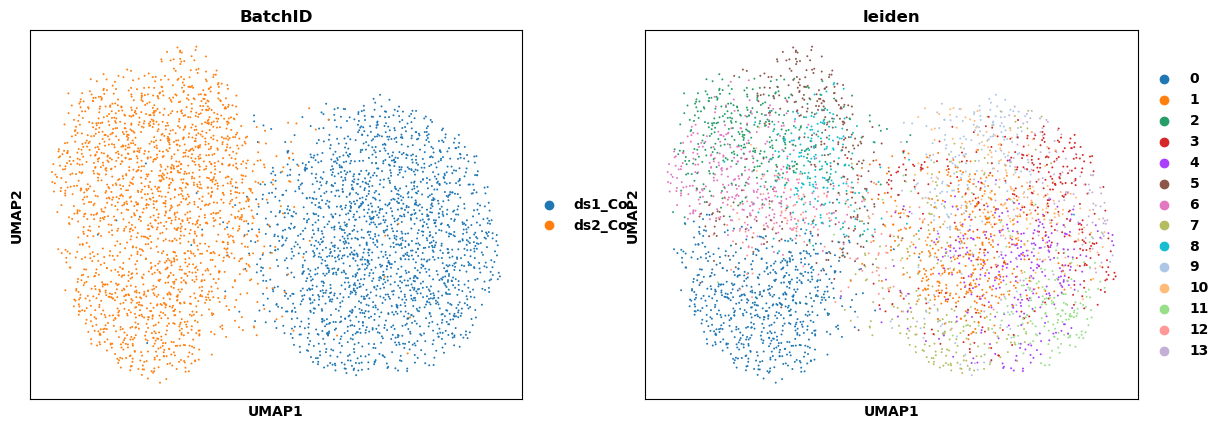

In [13]:
sc.pl.umap(
    adata,
    color=["BatchID", "leiden"],
    # Setting a smaller point size to get prevent overlap
    size=8,
)

In [14]:
import pandas as pd
import numpy as np
import scanpy as sc

# Check if adata.X is a sparse matrix, convert to dense if necessary
# This makes your code robust to different data formats
if isinstance(adata.X, np.ndarray):
    gene_expression_matrix = adata.X.T
else: # assuming it's a sparse matrix
    gene_expression_matrix = adata.X.T.toarray()

# Create the DataFrame
gene_expression_df = pd.DataFrame(
    gene_expression_matrix,
    index=adata.var_names,
    columns=adata.obs_names
)

# Calculate the correlation matrix.
corr_matrix = gene_expression_df.T.corr(method='pearson')

# Filter for strong correlations to simplify the network.
# A common threshold is an absolute correlation of 0.5 or higher.
threshold = 0.1
adj_matrix = np.where(np.abs(corr_matrix) > threshold, corr_matrix, 0)
np.fill_diagonal(adj_matrix, 0)

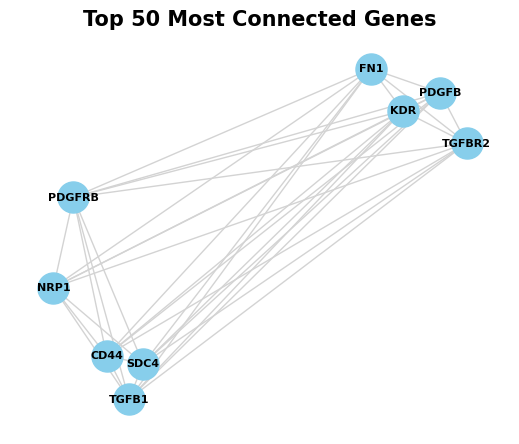

In [15]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph object from the adjacency matrix
G = nx.from_numpy_array(adj_matrix)

# Map the integer indices back to gene names
gene_names = adata.var_names
mapping = {i: gene_names[i] for i in range(len(gene_names))}
G = nx.relabel_nodes(G, mapping)

# Remove nodes that have no connections (isolated genes)
G.remove_nodes_from(list(nx.isolates(G)))

# To get a cleaner plot of a sub-network, you can find the most highly connected genes
degrees = dict(G.degree())
most_connected_genes = sorted(degrees, key=degrees.get, reverse=True)[:50]
subgraph = G.subgraph(most_connected_genes)

# Set a new layout specifically for the subgraph
subgraph_pos = nx.fruchterman_reingold_layout(subgraph)

plt.figure(figsize=(5, 4))
nx.draw(subgraph,
        pos=subgraph_pos,  # Use the new layout here
        with_labels=True,
        node_size=500,
        font_size=8,
        node_color='skyblue',
        edge_color='lightgray')
plt.title("Top 50 Most Connected Genes", fontsize=15)
plt.show()

In [ ]:
# Saving mono cultured simulation
# Create the circuit using the function
# ang_4g = [np.pi*0.2, np.pi*0.5, np.pi*0.4, np.pi*0.3, np.pi*0.7]
# circuit_4g = create_rotation_circuit(ang_4g)

# # Create the circuit using the function
# ang_3g = [np.pi*0.4, np.pi*0.4, np.pi*0.3, np.pi*0.6, np.pi*0.6]
# circuit_3g = create_rotation_circuit(ang_3g)

# Create the circuit using the function
ang_4g = [np.pi*0.2, np.pi*0.1, np.pi*0.4, np.pi*0.9, np.pi*0.8]
circuit_4g = create_rotation_circuit(ang_4g)
# Fn1 the last

# Create the circuit using the function
ang_3g = [np.pi*0.2, np.pi*0.3, np.pi*0.2, np.pi*0.7, np.pi*0.5]
circuit_3g = create_rotation_circuit(ang_3g)
# the last 2 are Cd44 and Sdc4

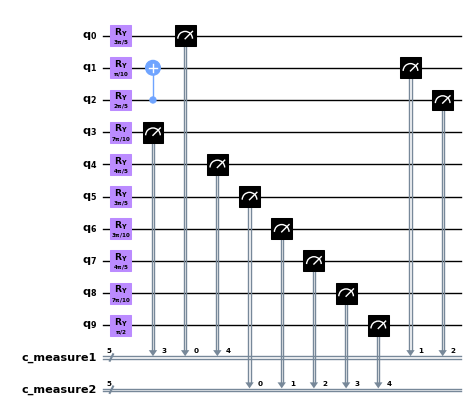

In [17]:
circuit_xct = concatenate_circuits_with_separate_measurements(circuit_4g, circuit_3g)
#interaction_map = list([(0,1), (2,1), (2,3), 
#                        (6,5), (5, 7)])
interaction_map = list([(2,1)])

#interaction_map = list([(1, 0)])

circuit_xct_cnot = add_cnots_and_measurements_to_circuit(circuit_xct, circuit_4g.num_qubits, interaction_map )
circuit_xct_cnot.draw(output="mpl", style="clifford", fold=40,  scale = 0.5)


--- Simulating and Plotting Histograms for: Greedy Optimized Circuit ---
Counts for c_measure1: {'10000': 80, '11000': 342, '11001': 612, '01001': 64, '10111': 86, '00000': 10, '11111': 307, '10110': 47, '01111': 29, '11110': 169, '10001': 139, '00001': 16, '10100': 1, '01110': 16, '00111': 8, '01000': 31, '11011': 14, '11010': 10, '11100': 1, '11101': 10, '10101': 3, '00110': 1, '10010': 1, '01101': 1, '10011': 2}
Counts for c_measure2: {'11101': 399, '10100': 50, '10110': 20, '10101': 107, '11111': 98, '01101': 365, '11100': 196, '01100': 198, '01111': 99, '00101': 120, '11000': 21, '11011': 7, '11010': 8, '01110': 53, '10111': 20, '11110': 34, '01000': 13, '00111': 27, '00100': 44, '00011': 2, '01001': 37, '10001': 9, '10010': 4, '00000': 4, '11001': 35, '01010': 2, '00110': 14, '01011': 5, '00001': 6, '10011': 2, '00010': 1}


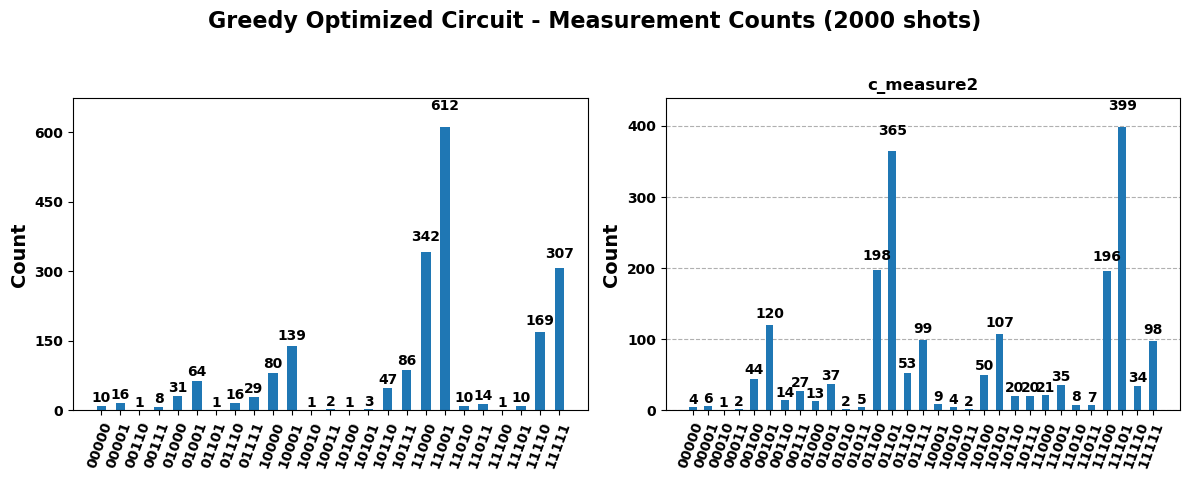

In [18]:
counts_measure1, counts_measure2 = plot_measurement_histograms(circuit_xct_cnot, nshots=2000, title_prefix="Greedy Optimized Circuit")

In [19]:
# Reconstruct the matrix
reconstructed_matrix = create_binary_matrix(counts_measure1)
print("Reconstructed Binary Matrix 1:")
print(reconstructed_matrix)
print("\nShape of the reconstructed matrix 1:", reconstructed_matrix.shape)
# Reconstruct the matrix
reconstructed_matrix2 = create_binary_matrix(counts_measure2)
print("Reconstructed Binary Matrix 1:")
print(reconstructed_matrix2)
print("\nShape of the reconstructed matrix 1:", reconstructed_matrix2.shape)

Reconstructed Binary Matrix 1:
[[0 0 0 0 1]
 [0 0 0 0 1]
 [0 0 0 0 1]
 ...
 [1 0 1 1 0]
 [1 1 0 0 1]
 [1 1 0 0 1]]

Shape of the reconstructed matrix 1: (2000, 5)
Reconstructed Binary Matrix 1:
[[1 0 1 1 1]
 [1 0 1 1 1]
 [1 0 1 1 1]
 ...
 [1 1 0 0 1]
 [1 1 0 0 1]
 [0 1 0 0 0]]

Shape of the reconstructed matrix 1: (2000, 5)


In [20]:
# Genes generated with stringdb:    https://string-db.org/cgi/network?taskId=bJEFw413SU2h&sessionId=bcTc0aENh3tL
# --- Step 1: Create the first AnnData object (representing one cell type) ---
print("Creating the first AnnData object (adata1)...")

# Simulating the first dataset's parameters
num_cells1 = 2000
gene_names1 = ['TGFBR2', 'FLT4', 'KDR', 'PDGFB', 'FN1']

# Set these genes to be highly expressed in this population
# mu_vector1 = np.array([0.8, 8, 6, 1, 3])
# r_vector1 = np.array([0.6, 0.9, 0.6, 0.4, 0.7])
mu_vector1 = np.array([5, 5, 5, 5, 5])
r_vector1 = np.array([1, 1, 1, 1, 1])

# Create dummy data for adata1
np.random.seed(100)
#binary_matrix1 = np.random.randint(0, 2, size=(num_cells1, len(gene_names1)))
count_matrix1 = create_count_matrix_nbinom(reconstructed_matrix, mu_vector1, r_vector1)

cell_ids1 = [f'cell_{i}_ds1_Mo' for i in range(num_cells1)]
obs1 = pd.DataFrame(index=cell_ids1)
var1 = pd.DataFrame(index=gene_names1)

# Create the AnnData object for the first dataset
adata1 = ad.AnnData(X=count_matrix1, obs=obs1, var=var1)
print(f"adata1 shape: {adata1.shape}")
print(f"adata1 genes: {adata1.var_names.tolist()}")

Creating the first AnnData object (adata1)...
adata1 shape: (2000, 5)
adata1 genes: ['TGFBR2', 'FLT4', 'KDR', 'PDGFB', 'FN1']


In [21]:
# --- Step 2: Create the second AnnData object (representing another cell type) ---
print("\nCreating the second AnnData object (adata2)...")

num_cells2 = 2000
gene_names2 = ['PDGFRB', 'NRP1', 'TGFB1', 'CD44', 'SDC4']

# Set these genes to be highly expressed in this population
# mu_vector2 = np.array([0.5, 3, 1.5, 1.1, 2])
# r_vector2 = np.array([0.4, 0.8, 0.5, 0.7, 0.7])
mu_vector2 = np.array([5, 5, 5, 5, 5])
r_vector2 = np.array([1, 1, 1, 1, 1])

# Create dummy data for adata2
np.random.seed(200)
#binary_matrix2 = np.random.randint(0, 2, size=(num_cells2, len(gene_names2)))
count_matrix2 = create_count_matrix_nbinom(reconstructed_matrix2, mu_vector2, r_vector2)
cell_ids2 = [f'cell_{i}_ds2_Mo' for i in range(num_cells2)]
obs2 = pd.DataFrame(index=cell_ids2)
var2 = pd.DataFrame(index=gene_names2)

# Create the AnnData object for the second dataset
adata2 = ad.AnnData(X=count_matrix2, obs=obs2, var=var2)
print(f"adata2 shape: {adata2.shape}")
print(f"adata2 genes: {adata2.var_names.tolist()}")



Creating the second AnnData object (adata2)...
adata2 shape: (2000, 5)
adata2 genes: ['PDGFRB', 'NRP1', 'TGFB1', 'CD44', 'SDC4']


In [23]:
# --- Step 3: Add housekeeping genes ---
print("\nAdding 10 random housekeeping genes to both datasets...")

num_housekeeping_genes = 50
housekeeping_gene_names = [f'HKG_{i}' for i in range(num_housekeeping_genes)]

# Housekeeping genes are highly and consistently expressed across all cells
mu_hkg = np.full(num_housekeeping_genes, 80.0)
r_hkg = np.full(num_housekeeping_genes, 6.0) # High r for low dispersion

# Create a binary matrix with 1s for all housekeeping genes across all cells
binary_matrix_hkg = np.ones((num_cells1 + num_cells2, num_housekeeping_genes), dtype=int)
count_matrix_hkg = create_count_matrix_nbinom(binary_matrix_hkg, mu_hkg, r_hkg)

# Create an AnnData object for the housekeeping genes
hkg_adata = ad.AnnData(
    X=count_matrix_hkg,
    obs=pd.DataFrame(index=list(adata1.obs_names) + list(adata2.obs_names)),
    var=pd.DataFrame(index=housekeeping_gene_names)
)

# --- Step 4: Merge the datasets ---
print("\nMerging all three AnnData objects...")

# First, merge adata1 and adata2 by cells
merged_cell_adata = ad.concat(
    [adata1, adata2],
    axis=0,
    join='outer',
    label='BatchID',
    keys=['ds1_Mo', 'ds2_Mo']
)

# Fill any NaN values with 0
merged_cell_adata.X[np.isnan(merged_cell_adata.X)] = 0

# Then, merge the combined dataset with the housekeeping genes by features
adata_mo = ad.concat(
    [merged_cell_adata, hkg_adata],
    axis=1,
    join='inner',
    merge='unique'
)

print("\nFinal Merged AnnData object created:")
print(adata_mo)
print(f"Merged shape: {adata_mo.shape}")
print(f"Merged genes: {adata_mo.var_names.tolist()}")



Adding 10 random housekeeping genes to both datasets...

Merging all three AnnData objects...

Final Merged AnnData object created:
AnnData object with n_obs × n_vars = 4000 × 60
    obs: 'BatchID'
Merged shape: (4000, 60)
Merged genes: ['CD44', 'FLT4', 'FN1', 'KDR', 'NRP1', 'PDGFB', 'PDGFRB', 'SDC4', 'TGFB1', 'TGFBR2', 'HKG_0', 'HKG_1', 'HKG_2', 'HKG_3', 'HKG_4', 'HKG_5', 'HKG_6', 'HKG_7', 'HKG_8', 'HKG_9', 'HKG_10', 'HKG_11', 'HKG_12', 'HKG_13', 'HKG_14', 'HKG_15', 'HKG_16', 'HKG_17', 'HKG_18', 'HKG_19', 'HKG_20', 'HKG_21', 'HKG_22', 'HKG_23', 'HKG_24', 'HKG_25', 'HKG_26', 'HKG_27', 'HKG_28', 'HKG_29', 'HKG_30', 'HKG_31', 'HKG_32', 'HKG_33', 'HKG_34', 'HKG_35', 'HKG_36', 'HKG_37', 'HKG_38', 'HKG_39', 'HKG_40', 'HKG_41', 'HKG_42', 'HKG_43', 'HKG_44', 'HKG_45', 'HKG_46', 'HKG_47', 'HKG_48', 'HKG_49']


In [24]:
# --- Step 6: Processing the data with Scanpy ---
print("\nStarting data processing with Scanpy...")

# Load the merged AnnData object
adata = adata_mo.copy()

# The 'batch' column is already in obs from the `ad.concat` step.
print("\nDataset batches are now stored in adata.obs['batch']:")
print(adata.obs['BatchID'].value_counts())

# --- 6.1 Quality Control (QC) and Metrics ---
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=None)

# --- 6.2 Normalization and Log-Transformation ---
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# --- 6.3 Scaling the Data ---
sc.pp.scale(adata, max_value=10)

# --- 6.4 Principal Component Analysis (PCA) ---
# Check if the number of genes is sufficient for PCA
if adata.n_vars > 0:
    sc.tl.pca(adata, svd_solver='arpack')
else:
    print("\nNo genes remaining after filtering. Skipping PCA.")

# --- 6.5 UMAP (Uniform Manifold Approximation and Projection) ---
# Set n_pcs to be the minimum of 20 and the number of genes
n_pcs = min(10, adata.n_vars)
if adata.n_vars > 1:
    sc.pp.neighbors(adata, n_neighbors=10, n_pcs=n_pcs)
    sc.tl.umap(adata)
    sc.tl.leiden(adata, flavor="leidenalg", n_iterations=2)

else:
    print("\nNot enough genes to compute neighbors and UMAP. Skipping.")

# --- 6.7 Final Output ---
print("\nFinal AnnData object after UMAP has been computed:")
print(adata)
print("\nUMAP coordinates are stored in adata.obsm['X_umap'].")
print("PCA coordinates are stored in adata.obsm['X_pca'].")



Starting data processing with Scanpy...

Dataset batches are now stored in adata.obs['batch']:
BatchID
ds1_Mo    2000
ds2_Mo    2000
Name: count, dtype: int64

Final AnnData object after UMAP has been computed:
AnnData object with n_obs × n_vars = 4000 × 60
    obs: 'BatchID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

UMAP coordinates are stored in adata.obsm['X_umap'].
PCA coordinates are stored in adata.obsm['X_pca'].


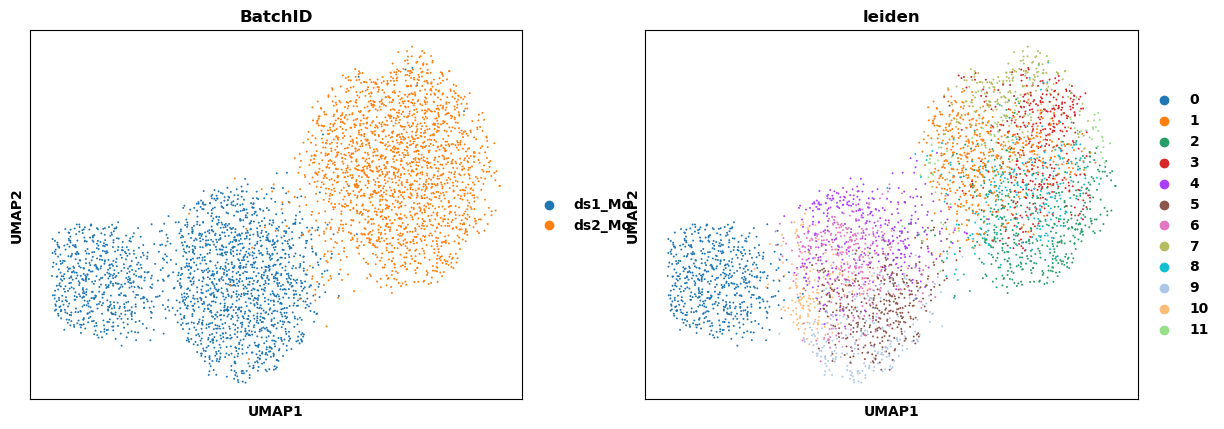

In [25]:
sc.pl.umap(
    adata,
    color=["BatchID", "leiden"],
    # Setting a smaller point size to get prevent overlap
    size=8,
)

In [26]:
import numpy as np
import pandas as pd
import scanpy as sc 

#adata_mo = adata2 #sc.read_h5ad("merged_datasets_mo.h5ad")

adata_mo.obs['CellType'] = None
adata_mo.obs['Batch2'] = 'Mo'

# Assign 'CAF' where the 'batch' is 'ds1'.
adata_mo.obs.loc[adata_mo.obs['BatchID'] == 'ds1_Mo', 'CellType'] = 'CAF'

# Assign 'Fibroblasts' where the 'batch' is 'ds2'.
adata_mo.obs.loc[adata_mo.obs['BatchID'] == 'ds2_Mo', 'CellType'] = 'Fibroblasts'
adata_mo.obs['CellType'] = adata_mo.obs['CellType'].astype('category')

print(adata_mo.obs['CellType'].head())

cell_0_ds1_Mo    CAF
cell_1_ds1_Mo    CAF
cell_2_ds1_Mo    CAF
cell_3_ds1_Mo    CAF
cell_4_ds1_Mo    CAF
Name: CellType, dtype: category
Categories (2, object): ['CAF', 'Fibroblasts']


In [27]:
adata_mo.obs['BatchID']

cell_0_ds1_Mo       ds1_Mo
cell_1_ds1_Mo       ds1_Mo
cell_2_ds1_Mo       ds1_Mo
cell_3_ds1_Mo       ds1_Mo
cell_4_ds1_Mo       ds1_Mo
                     ...  
cell_1995_ds2_Mo    ds2_Mo
cell_1996_ds2_Mo    ds2_Mo
cell_1997_ds2_Mo    ds2_Mo
cell_1998_ds2_Mo    ds2_Mo
cell_1999_ds2_Mo    ds2_Mo
Name: BatchID, Length: 4000, dtype: category
Categories (2, object): ['ds1_Mo', 'ds2_Mo']

In [28]:
import numpy as np
import pandas as pd
import scanpy as sc 

adata_co.obs['CellType'] = None
adata_co.obs['Batch2'] = 'Co'

# Assign 'CAF' where the 'batch' is 'ds1'.
adata_co.obs.loc[adata_co.obs['BatchID'] == 'ds1_Co', 'CellType'] = 'CAF'

# Assign 'Fibroblasts' where the 'batch' is 'ds2'.
adata_co.obs.loc[adata_co.obs['BatchID'] == 'ds2_Co', 'CellType'] = 'Fibroblasts'
adata_co.obs['CellType'] = adata_co.obs['CellType'].astype('category')

print(adata_co.obs['CellType'].head())

cell_0_ds1_Co    CAF
cell_1_ds1_Co    CAF
cell_2_ds1_Co    CAF
cell_3_ds1_Co    CAF
cell_4_ds1_Co    CAF
Name: CellType, dtype: category
Categories (2, object): ['CAF', 'Fibroblasts']


In [29]:
import anndata as ad

# Assuming adata_mo and adata_co are already loaded
adatas = [adata_mo, adata_co]

adata_merged = ad.concat(
    adatas,
    join='inner',  # Keeps only the variables (genes) that are common to both datasets
    label='condition', # Creates a new column named 'condition' in adata_merged.obs
    keys=['monoculture', 'coculture'] # Populates the 'condition' column with 'monoculture' and 'coculture'
)

In [30]:
adata_merged

AnnData object with n_obs × n_vars = 8000 × 60
    obs: 'BatchID', 'CellType', 'Batch2', 'condition'

In [31]:
import scipy.sparse as sp
adata_merged.X = sp.csr_matrix(adata_merged.X)
adata_merged.write_h5ad('merged_datasets_co_mo.h5ad')